### Indoor

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../")
from datasets.dataloader import get_wireless_dataloader

dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    batch_size=16,
    num_pc=16378,
    drop_last=True,
)

In [2]:
for batch in dataloader:
    rx_position = batch["rx_position"]  # [B, 3]
    channel_matrix = batch["channel_matrix"]  # [B, tx_ant, rx_ant, 2]
    aoa = batch["aoa"]  # list of B tensors, each with shape [2, num_paths]
    path_loss = batch["path_loss"]  # [B]

# verify shapes from dataloader
print("Dataloader shapes:")
print(f"RX position: {batch['rx_position'].shape}")
print(f"Channel matrix: {batch['channel_matrix'].shape}")
print(f"Path loss: {batch['path_loss'].shape}")

print("\nAoD/AoA shapes (per batch item):")
print(f"AoA: {batch['aoa'][0].shape}")

Dataloader shapes:
RX position: torch.Size([16, 3])
Channel matrix: torch.Size([16, 16, 2, 2])
Path loss: torch.Size([16])

AoD/AoA shapes (per batch item):
AoA: torch.Size([2, 16])


Visualize $\textbf{H}$ as an Image $I$

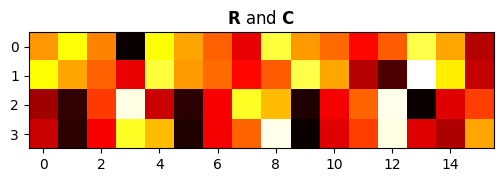

In [15]:
idx = 0  # select first item in batch
channel = channel_matrix[idx].numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

combined_image = np.hstack((np.abs(channel[:, :, 0]), np.abs(channel[:, :, 1])))
ax.imshow(combined_image.transpose(), cmap="hot", interpolation="nearest")
ax.set_title(r"$\mathbf{R}$ and $\mathbf{C}$")

plt.show()

### Outdoor

In [17]:
dataloader = get_wireless_dataloader(
    "../datasets/outputs/iab_64x2_2268u_6.0ghz_sbrRT_sc312.mat",
    batch_size=16,
    num_pc=32756,
    drop_last=True,
)

In [18]:
for batch in dataloader:
    rx_position = batch["rx_position"]  # [B, 3]
    channel_matrix = batch["channel_matrix"]  # [B, tx_ant, rx_ant, 2]
    aoa = batch["aoa"]  # list of B tensors, each with shape [2, num_paths]
    path_loss = batch["path_loss"]  # [B]

# verify shapes from dataloader
print("Dataloader shapes:")
print(f"RX position: {batch['rx_position'].shape}")
print(f"Channel matrix: {batch['channel_matrix'].shape}")
print(f"Path loss: {batch['path_loss'].shape}")

print("\nAoD/AoA shapes (per batch item):")
print(f"AoA: {batch['aoa'][0].shape}")

Dataloader shapes:
RX position: torch.Size([16, 3])
Channel matrix: torch.Size([16, 64, 2, 2])
Path loss: torch.Size([16])

AoD/AoA shapes (per batch item):
AoA: torch.Size([2, 37])


Visualize $\textbf{H}$ as an Image $I$

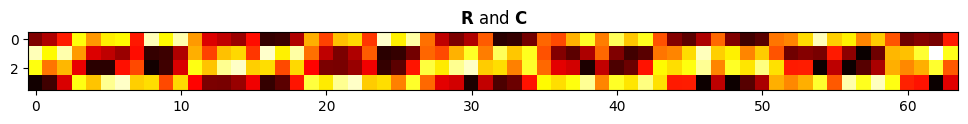

In [20]:
idx = 0  # select first item in batch
channel = channel_matrix[idx].numpy()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

combined_image = np.hstack((np.abs(channel[:, :, 0]), np.abs(channel[:, :, 1])))
ax.imshow(combined_image.transpose(), cmap="hot", interpolation="nearest")
ax.set_title(r"$\mathbf{R}$ and $\mathbf{C}$")

plt.show()